In [2]:
using JSON
using Plots


In [3]:
# -----------------------------
# SALVATAGGIO (più flessibile)
# -----------------------------
function save_CCE_results(filename, x_pos, CCE_mean, CCE_std; params=nothing)

    results = Dict(
        "x_pos" => collect(x_pos),
        "CCE_mean" => CCE_mean,
        "CCE_std" => CCE_std
    )

    # aggiunge params solo se forniti
    if params !== nothing
        results["params"] = params
    end

    open(filename, "w") do f
        JSON.print(f, results, 4)
    end

    println("Salvato file: ", filename)
end


# -----------------------------
# LETTURA (robusta)
# -----------------------------
function load_CCE_results(filename)

    data = JSON.parsefile(filename)

    # --- caso 1: formato semplice (il tuo attuale)
    if haskey(data, "x_pos")
        x   = Float64.(data["x_pos"])
        cce = Float64.(data["CCE_mean"])
        err = Float64.(data["CCE_std"])
        params = haskey(data, "params") ? data["params"] : Dict()

    # --- caso 2: formato annidato
    elseif haskey(data, "data")
        d = data["data"]
        x   = Float64.(d["x_pos"])
        cce = Float64.(d["CCE_mean"])
        err = Float64.(d["CCE_std"])
        params = haskey(data, "params") ? data["params"] : Dict()

    else
        error("Formato JSON non riconosciuto")
    end

    return x, cce, err, params
end

load_CCE_results (generic function with 1 method)

# CONFRONTO GIOVANETTI vs MIO CODICE CON 1 Litio - size

In [12]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 1000 charges, 25 rep
xR, cceR, errR, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con il codice mio, dx = 20 um, 1000 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/My-uncomplete-model.json");

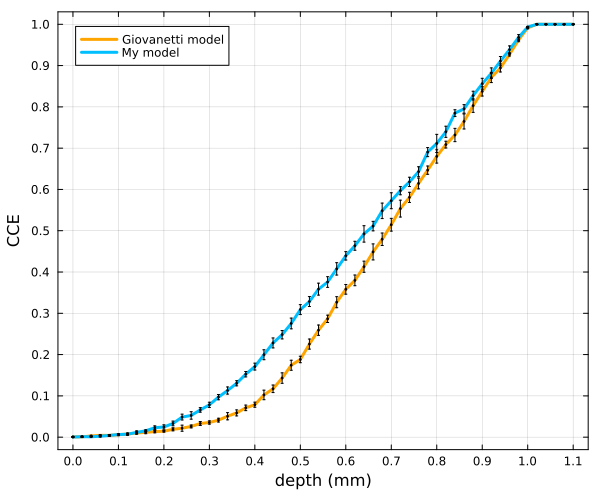

In [19]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1

plt = plot(xR.*10, cceR, lw=3, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Giovanetti model",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(xMM.*10, cceMM, lw=3, color=:deepskyblue, label = "My model")


plot!(
    xR.*10, cceR,
    yerr=errR,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false,
)


plot!(
    xMM.*10, cceMM,
    yerr=errMM,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false
)

savefig(plt, "plot/CCE_comparison.png")
display(plt)

# CONFRONTO MIO MODELLO CON 1 LITIO vs DIEMENSIONE LITIO RANDOMICA

In [5]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
x_1Li, cce_1Li, err_1Li, params_loaded = load_CCE_results("my model/My-uncomplete-model.json");
# questa è la curva CCE fatta con il codice mio, dx = 20 um, 1000 charges, 25 rep
x_RLi, cce_RLi, err_RLi, params_loaded = load_CCE_results("my model/random-Li.json");


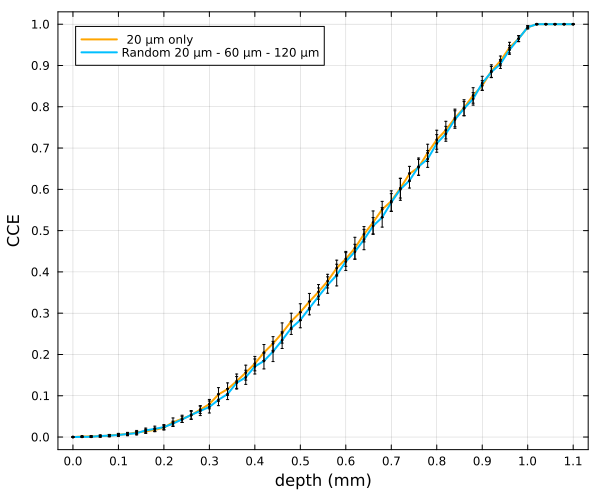

In [12]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1

plt = plot(x_1Li.*10, cce_1Li, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label=" 20 μm only",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(x_RLi.*10, cce_RLi, lw=2, color=:deepskyblue, label = "Random 20 μm - 60 μm - 120 μm")


plot!(
    x_1Li.*10, cce_1Li,
    yerr=err_1Li,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false,
)


plot!(
    x_RLi.*10, cce_RLi,
    yerr=err_RLi,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false
)

savefig(plt, "plot/CCE_comparison_different_Li_sizes.png")
display(plt)